## Code to run linear and polynomial regression on the algae bloom data

### <b>Load necessary packages</b>

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, KFold, LeaveOneGroupOut

from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, ElasticNetCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, average_precision_score, f1_score
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix

%matplotlib inline

### <b>Set file info </b>

In [2]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### <b>Read in algae bloom data</b>

In [3]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_year,vct_day_of_year,vct_latitude,vct_longitude,vct_water_temp_7days,vct_water_surface_7days,vct_target_bloom_intensity_7days,vct_anabaena_7days,...,noaa_wind_direction_5_min,noaa_air_temp_mean,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,2014,273,44.484736,-73.288936,68.240,1.516667,1.550000,0.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1.000
1,Main Lake Central,2014-10-02,2014,275,44.484736,-73.288936,68.240,1.220000,1.550000,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3.000
2,Main Lake Central,2015-06-14,2015,165,44.484736,-73.288936,70.175,1.125000,1.821429,1.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1.125
3,Main Lake Central,2015-06-15,2015,166,44.484736,-73.288936,68.090,1.200000,1.696429,1.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1.000
4,Main Lake Central,2015-06-16,2015,167,44.484736,-73.288936,65.690,1.400000,1.553571,1.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1.000


### <b>Clean up and format columns</b>

In [4]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

53


Index(['vct_region', 'vct_report_date', 'vct_year', 'vct_day_of_year',
       'vct_latitude', 'vct_longitude', 'vct_water_temp_7days',
       'vct_water_surface_7days', 'vct_target_bloom_intensity_7days',
       'vct_anabaena_7days', 'vct_aphanizomenon_7days',
       'vct_microcystin_7days', 'vct_oscillatoria_7days',
       'vct_target_bloom_7days', 'vct_water_temp_14days',
       'vct_water_surface_14days', 'vct_target_bloom_intensity_14days',
       'vct_anabaena_14days', 'vct_aphanizomenon_14days',
       'vct_microcystin_14days', 'vct_oscillatoria_14days',
       'vct_target_bloom_14days', 'usgs_water_temp_max_7days',
       'usgs_water_temp_min_7days', 'usgs_water_temp_mean_7days',
       'usgs_conductivity_max_7days', 'usgs_conductivity_min_7days',
       'usgs_conductivity_mean_7days', 'usgs_water_temp_max_14days',
       'usgs_water_temp_min_14days', 'usgs_water_temp_mean_14days',
       'usgs_conductivity_max_14days', 'usgs_conductivity_min_14days',
       'usgs_conductivity_m

In [5]:
# Convert columns to floats, integers, and dates as appropriate

algae_numcols_df = algae_raw_df.copy()

date_cols = ["vct_report_date"]

string_cols = ["vct_region"]

integer_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_target_bloom",
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_day_of_year",
    "vct_year"
]

# Format date columns
algae_numcols_df[date_cols] = (
    algae_numcols_df[date_cols]
    .apply(pd.to_datetime, errors="coerce")
)

# Format string columns
algae_numcols_df[string_cols] = algae_numcols_df[string_cols].astype("string")

# Format integer columns (nullable)
algae_numcols_df[integer_cols] = (
    algae_numcols_df[integer_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")
)

# Format all remaining columns as floats
float_cols = algae_numcols_df.columns.difference(string_cols + integer_cols + date_cols)

algae_numcols_df[float_cols] = (
    algae_numcols_df[float_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
)

In [6]:
# Remove 2014 (only two observations)

# algae_numcols_df.head()
print("With 2014:", len(algae_numcols_df))

algae_goodyears_df = algae_numcols_df[algae_numcols_df["vct_year"] != 2014]

print("Without 2014:", len(algae_goodyears_df))


With 2014: 2919
Without 2014: 2914


In [7]:
# Figure out baseline bloom percentage

total_records = len(algae_goodyears_df)
records_with_blooms = len(algae_goodyears_df[algae_goodyears_df["vct_target_bloom"] == 1])
percent_blooms = records_with_blooms / total_records

print(percent_blooms)

0.24262182566918325


### <b>Define the file structure</b>

In [8]:
# Define column types

algae_model_df = algae_goodyears_df.copy()

target_cols = ["vct_target_bloom", "vct_target_bloom_intensity"]

meta_cols = ["vct_report_date", "vct_year"]

exclude_cols = ["vct_region", "vct_latitude", "vct_longitude"]

trailing_7day_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_water_temp_7days",
    "vct_water_surface_7days",
    "usgs_conductivity_mean_7days",
    # "usgs_water_temp_mean_7days"
]

trailing_14day_cols = [
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_water_temp_14days",
    "vct_water_surface_14days",
    "usgs_conductivity_mean_14days",
    "usgs_water_temp_mean_14days"
]

trailing_target_cols = [
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_target_bloom_intensity_7days",
    "vct_target_bloom_intensity_14days"
]

correlated_cols = ["dec_temperature", 
                   "usgs_water_temp_max_7days", "usgs_water_temp_min_7days",
                   "usgs_water_temp_max_14days", "usgs_water_temp_min_14days",
                   "usgs_conductivity_max_7days", "usgs_conductivity_min_7days",
                   "usgs_conductivity_max_14days", "usgs_conductivity_min_14days",
                   "noaa_air_temp_max", "noaa_air_temp_min", "noaa_air_temp_mean",
                   "dec_dissolved phosphorus",
                   "usgs_water_temp_mean_7days"
]

# Define unhelpful columns based on coefficient testing later on in the notebook (for feature pruning)
unhelpful_cols = ["noaa_snow_depth", "noaa_snowfall", "noaa_precipitation",
                  "noaa_wind_speed_2_min", "noaa_wind_speed_5_min", "noaa_wind_speed_mean", 
                  "noaa_wind_direction_5_min", 
                  # "noaa_wind_direction_2_min",
                  "vct_water_surface_7days", 
                  # "vct_oscillatoria_7days", "vct_aphanizomenon_7days",
                  "usgs_conductivity_mean_7days",
                  # "usgs_water_temp_mean_7days",
                  "dec_secchi depth", 
                  # "dec_total nitrogen"
]

# Include only 7-day trailing cols in features
# And do not include trailing_target_cols in features yet
other_cols = algae_model_df.columns.difference(meta_cols + correlated_cols + trailing_7day_cols + trailing_14day_cols + trailing_target_cols + target_cols + exclude_cols)
full_feature_cols = trailing_7day_cols + list(other_cols)
# feature_cols = trailing_7day_cols + list(other_cols)
feature_cols = [col for col in full_feature_cols if col not in unhelpful_cols]

feature_cols

['vct_anabaena_7days',
 'vct_aphanizomenon_7days',
 'vct_microcystin_7days',
 'vct_oscillatoria_7days',
 'vct_water_temp_7days',
 'dec_chlorophyll-a',
 'dec_total nitrogen',
 'dec_total phosphorus',
 'noaa_wind_direction_2_min',
 'vct_day_of_year']

### <b>Split the data into training and test sets</b>

In [9]:
# Create train set and test sets

# We changed the split to hold out 2021 and 2022 for testing, instead of doing a random split
# lr_train_set, lr_test_set = train_test_split(algae_model_df, test_size=0.2, random_state=17)

# Define years to hold out for testing
test_years = [2021, 2022]

# Training set should be all rows *not* in the test years
lr_train_set = algae_model_df[~algae_model_df["vct_year"].isin(test_years)].copy()

# Test set should be all rows *in* the test years
lr_test_set = algae_model_df[algae_model_df["vct_year"].isin(test_years)].copy()

print("Train set:", len(lr_train_set))
print("Test set:", len(lr_test_set))

Train set: 2127
Test set: 787


### <b>Create feature, target, and meta data</b>

##### Create feature, target, and meta data for training data

In [10]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_train_features = lr_train_set[feature_cols].copy()
algae_train_target_bloom = lr_train_set["vct_target_bloom"].copy()
algae_train_target_intensity = lr_train_set["vct_target_bloom_intensity"].copy()
algae_train_meta = lr_train_set[meta_cols].copy()

# Force all feature columns to be numeric

X_train_features_df = algae_train_features.apply(pd.to_numeric, errors="coerce")

In [11]:
# Print out columns that have NaNs

cols_with_nans = X_train_features_df.columns[X_train_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_train_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 63 NaNs
dec_chlorophyll-a - 148 NaNs
dec_total nitrogen - 151 NaNs
dec_total phosphorus - 151 NaNs
['vct_water_temp_7days', 'dec_chlorophyll-a', 'dec_total nitrogen', 'dec_total phosphorus']


In [12]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_train_features = X_train_features_df.to_numpy() # converts feature dataframe into an array
y_lr_train_bloom = np.asarray(algae_train_target_bloom) # converts target series into a vector
y_lr_train_intensity = np.asarray(algae_train_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_train_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_train_theta = np.zeros((X_train_features_df.shape[1], 1))

# Print shapes
print("X_train_features_df shape:", X_train_features_df.shape)
print("y_lr_train_bloom shape:", y_lr_train_bloom.shape)
print("y_lr_train_intensity shape:", y_lr_train_intensity.shape)
print("lr_train_theta shape:", lr_train_theta.shape)

X_train_features_df shape: (2127, 10)
y_lr_train_bloom shape: (2127,)
y_lr_train_intensity shape: (2127,)
lr_train_theta shape: (10, 1)


##### Create features, targets, and meta data for test data

In [13]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_test_features = lr_test_set[feature_cols].copy()
algae_test_target_bloom = lr_test_set["vct_target_bloom"].copy()
algae_test_target_intensity = lr_test_set["vct_target_bloom_intensity"].copy()
algae_test_meta = lr_test_set[meta_cols].copy()

# Force all feature columns to be numeric

X_test_features_df = algae_test_features.apply(pd.to_numeric, errors="coerce")

In [14]:
# Print out columns that have NaNs

cols_with_nans = X_test_features_df.columns[X_test_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_test_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 58 NaNs
dec_chlorophyll-a - 104 NaNs
dec_total nitrogen - 95 NaNs
dec_total phosphorus - 95 NaNs
['vct_water_temp_7days', 'dec_chlorophyll-a', 'dec_total nitrogen', 'dec_total phosphorus']


In [15]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_test_features = X_test_features_df.to_numpy() # converts feature dataframe into an array
y_lr_test_bloom = np.asarray(algae_test_target_bloom) # converts target series into a vector
y_lr_test_intensity = np.asarray(algae_test_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_test_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_test_theta = np.zeros((X_test_features_df.shape[1], 1))

# Print shapes
print("X_test_features_df shape:", X_test_features_df.shape)
print("y_lr_test_bloom shape:", y_lr_test_bloom.shape)
print("y_lr_test_intensity shape:", y_lr_test_intensity.shape)
print("lr_test_theta shape:", lr_test_theta.shape)

X_test_features_df shape: (787, 10)
y_lr_test_bloom shape: (787,)
y_lr_test_intensity shape: (787,)
lr_test_theta shape: (10, 1)


### <b>Train the bloom presence model with cross-validation</b>

In [16]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_bloom = LeaveOneGroupOut()

In [17]:
# Fill in NaN columns in the training data with means

# X_train_features_temp_df = X_train_features_df.copy()
# X_test_features_temp_df = X_test_features_df.copy()

X_train_features_df[nan_cols] = X_train_features_df[nan_cols].fillna(X_train_features_df[nan_cols].mean())

# Save training means for using in imputing test data
train_means = X_train_features_df[nan_cols].mean()

# Check to make sure there are no more NaNs
nan_counts = X_train_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

# Fill in NaN columns in the test data with means from the training data

X_test_features_df[nan_cols] = X_test_features_df[nan_cols].fillna(train_means)

# Check to make sure there are no more NaNs
nan_counts = X_test_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [18]:
# Find the best alpha and l1_ratio for regularization

enet_cv_model = ElasticNetCV(
    l1_ratio=[0.00001, 0.000025, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.03],  # values to try
    cv=logo_bloom.split(X_train_features_df, y_lr_train_bloom, groups=groups),
    fit_intercept=True
)
enet_cv_model.fit(X_train_features_df, y_lr_train_bloom)
print("Best alpha:", enet_cv_model.alpha_)
print("Best l1_ratio:", enet_cv_model.l1_ratio_)

Best alpha: 0.23931760918674944
Best l1_ratio: 0.01


In [19]:
# Set regularization alpha for all models, using optimal values from above

reg_alpha = 0.16780683414265007
reg_l1_ratio = 0.00005

In [20]:
# Create the model

# lr_bloom_model = LinearRegression(fit_intercept=True)
# lr_bloom_model = Lasso(alpha=reg_alpha, fit_intercept=True)
# lr_bloom_model = ElasticNet(alpha=reg_alpha, l1_ratio=reg_l1_ratio, fit_intercept=True)

# Define a pipeline to impute NaNs, scale the data, and define the model
# within the cross-validation
# Use ElasticNetCV to handle multiple correlated features better than regular elastic net
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("model", ElasticNetCV(l1_ratio=reg_l1_ratio, fit_intercept=True))
])

# Do cross-validation one year at a time
cv_results = cross_validate(
    pipeline,
    X_lr_train_features,
    y_lr_train_bloom,
    cv=logo_bloom.split(X_lr_train_features, y_lr_train_bloom, groups=groups),
    scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
    # scoring=["roc_auc", "accuracy", "precision", "recall", "f1"],
)

# Scores for each cross-validation fold:
for metric, values in cv_results.items():
    if metric.startswith("test_"):
        display_values = -values.round(4) if "neg_" in metric else values.round(4)
        print(metric, display_values.mean().round(4), display_values)
        # print(metric, values.mean().round(4), values.round(4))

# Fit the model
pipeline.fit(X_lr_train_features, y_lr_train_bloom)

# Check the R2 score on the training set
lr_bloom_train_r2 = pipeline.score(X_lr_train_features, y_lr_train_bloom)
print("Training R2:", lr_bloom_train_r2)

# Get predictions from the model
y_pred_bloom_test = pipeline.predict(X_lr_test_features)

# Check the R2 score on the test set
lr_bloom_test_r2 = pipeline.score(X_lr_test_features, y_lr_test_bloom)
print("Test R2:", lr_bloom_test_r2)

# Print out coefficients and intercept
# print("Coefficients:", pipeline.named_steps["model"].coef_)
# print("Intercept:", pipeline.named_steps["model"].intercept_)

test_r2 0.0711 [0.1246 0.1251 0.0834 0.065  0.0105 0.0178]
test_neg_mean_squared_error 0.1647 [0.1456 0.1355 0.1587 0.1713 0.2045 0.1725]
test_neg_mean_absolute_error 0.3403 [0.3289 0.3134 0.3435 0.3487 0.3767 0.3304]
Training R2: 0.07804563619394933
Test R2: 0.03870205431023255


### <b>Calculate performance metrics for bloom presence model</b>


Best threshold (max F1): 0.2549
Best F1 score: 0.4909

Manual classification metrics (threshold=0.2548586385472903):
Accuracy: 0.750
Precision: 0.469
Recall: 0.515
F1: 0.491


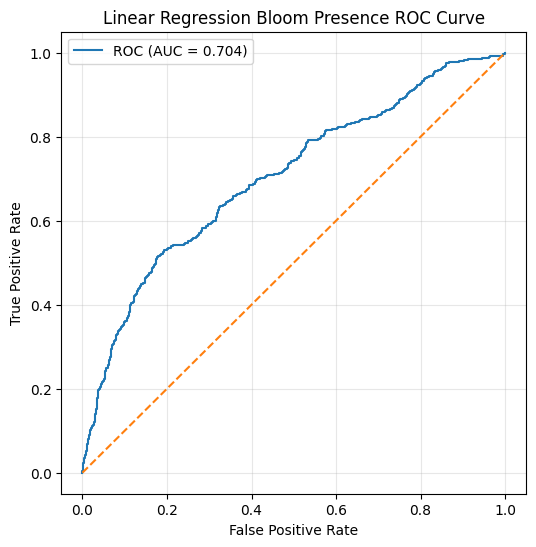

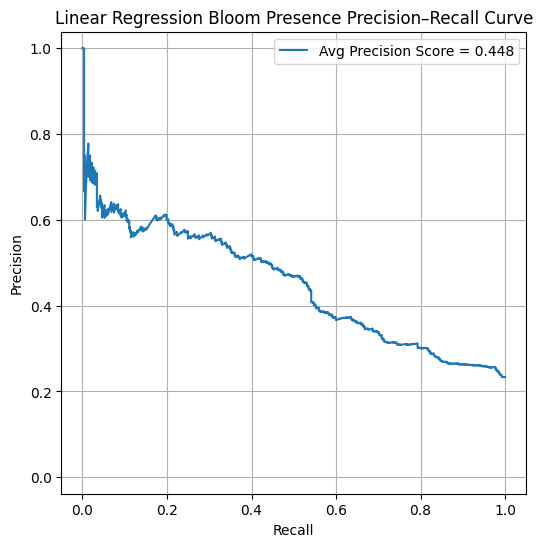

In [31]:
# Plot ROC Curve

# Get out-of-fold predictions (raw regression scores, not probabilities)
y_out_of_fold_scores = cross_val_predict(
    pipeline,
    X_lr_train_features,
    y_lr_train_bloom,
    groups=groups,
    cv=logo_bloom.split(X_lr_train_features, y_lr_train_bloom, groups=groups),
    method="predict" # Because I have a regressor, not a classifier
)

# Calculate classifier metrics using best threshold to maximize F1 score

# Calculate continuous scores
precision, recall, thresholds = precision_recall_curve(
    y_lr_train_bloom,
    y_out_of_fold_scores
)

# Compute F1 scores
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# Find best threshold
best_idx = np.argmax(f1_scores[:-1])  # exclude last point (no threshold)
best_threshold = thresholds[best_idx]

print(f"\nBest threshold (max F1): {best_threshold:.4f}")
print(f"Best F1 score: {f1_scores[best_idx]:.4f}")

threshold = best_threshold
y_pred_binary = (y_out_of_fold_scores >= threshold).astype(int)

accuracy = accuracy_score(y_lr_train_bloom, y_pred_binary)
precision = precision_score(y_lr_train_bloom, y_pred_binary)
recall = recall_score(y_lr_train_bloom, y_pred_binary)
f1 = f1_score(y_lr_train_bloom, y_pred_binary)

print(f"\nManual classification metrics (threshold={threshold}):")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

cv_auc = roc_auc_score(y_lr_train_bloom, y_out_of_fold_scores)
fpr, tpr, _ = roc_curve(y_lr_train_bloom, y_out_of_fold_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {cv_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear Regression Bloom Presence ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../figures/linear_regression_bloom_presence_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_lr_train_bloom, y_out_of_fold_scores)

ap = average_precision_score(y_lr_train_bloom, y_out_of_fold_scores)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"Avg Precision Score = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Linear Regression Bloom Presence Precision–Recall Curve")
plt.legend()
plt.grid(True)

# Get current limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Compute how far above 1.0 the axis goes
x_pad = x_max - 1
y_pad = y_max - 1

# Set symmetric limits
plt.xlim(-x_pad, 1 + x_pad)
plt.ylim(-y_pad, 1 + y_pad)

plt.savefig("../figures/linear_regression_bloom_presence_pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### <b>Train the bloom intensity model using cross-validation</b>

test_r2 0.1239 [0.1558 0.2099 0.1104 0.1156 0.0794 0.0723]
test_neg_mean_squared_error 0.2289 [0.2768 0.2045 0.2555 0.2619 0.2097 0.1649]
test_neg_mean_absolute_error 0.3532 [0.3862 0.3252 0.3858 0.373  0.3476 0.3017]


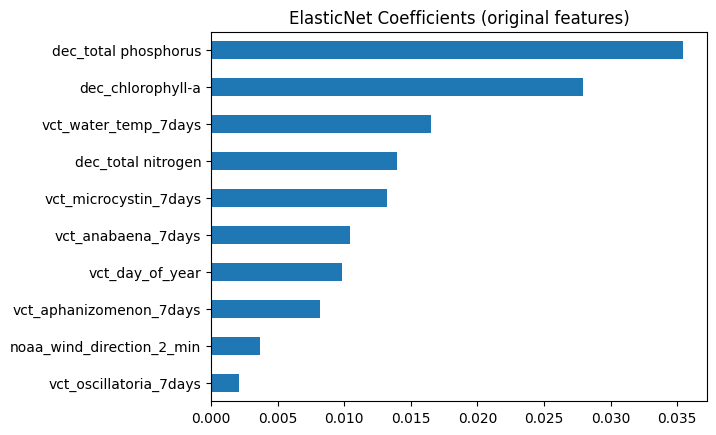

Training R2: 0.13561495398157242
Test R2: 0.1022922537554678


In [22]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_intensity = LeaveOneGroupOut()

# Create the model
# lr_intensity_model = LinearRegression(fit_intercept=True)
# lr_intensity_model = Lasso(alpha=reg_alpha, fit_intercept=True)
# lr_intensity_model = ElasticNet(alpha=reg_alpha, l1_ratio=reg_l1_ratio, fit_intercept=True)

# Define a pipeline to impute NaNs, scale the data, and define the model
# within the cross-validation
# Use ElasticNetCV to handle multiple correlated features better than regular elastic net
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("model", ElasticNetCV(l1_ratio=reg_l1_ratio, fit_intercept=True))
])

# Do cross-validation one year at a time
cv_results = cross_validate(
    pipeline,
    X_lr_train_features,
    y_lr_train_intensity,
    cv=logo_intensity.split(X_lr_train_features, y_lr_train_intensity, groups=groups),
    scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
)

# Scores for each cross-validation fold:
for metric, values in cv_results.items():
    if metric.startswith("test_"):
        display_values = -values.round(4) if "neg_" in metric else values.round(4)
        print(metric, display_values.mean().round(4), display_values)
        # print(metric, values.mean().round(4), values.round(4))

# Fit the model
pipeline.fit(X_lr_train_features, y_lr_train_intensity)

# Check coefficient importance
# Convert X_lr_train_features to a DataFrame
X_lr_train_features_df = pd.DataFrame(X_lr_train_features, columns=feature_cols)
# Now plotting works
coef = pipeline.named_steps["model"].coef_
feature_importance = pd.Series(coef, index=X_lr_train_features_df.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("ElasticNet Coefficients (original features)")
plt.show()

# Check the R2 score on the training set
lr_intensity_train_r2 = pipeline.score(X_lr_train_features, y_lr_train_intensity)
print("Training R2:", lr_intensity_train_r2)

# Get predictions from the model
y_pred_intensity_test = pipeline.predict(X_lr_test_features)

# Check the R2 score on the test set
lr_intensity_test_r2 = pipeline.score(X_lr_test_features, y_lr_test_intensity)
print("Test R2:", lr_intensity_test_r2)

# print("CV R2 per year:", cv_r2_scores)
# print("Mean CV R2:", np.mean(cv_r2_scores))
# print("Standard deviation of CV R^2:", np.std(cv_r2_scores))

# Print out coefficients and intercept
# print("Coefficients:", pipeline.named_steps["model"].coef_)
# print("Intercept:", pipeline.named_steps["model"].intercept_)

### <b>Calculate performance metrics for bloom intensity model</b>

In [23]:
# Generate predictions on the test set
y_pred_intensity_test = pipeline.predict(X_lr_test_features)

# True values
y_true_intensity = y_lr_test_intensity

# Evaluation metrics
r2 = r2_score(y_true_intensity, y_pred_intensity_test)
rmse = np.sqrt(mean_squared_error(y_true_intensity, y_pred_intensity_test))
mae = mean_absolute_error(y_true_intensity, y_pred_intensity_test)

print("Bloom intensity model performance:")
print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")

Bloom intensity model performance:
R²   : 0.102
RMSE : 0.467
MAE  : 0.338


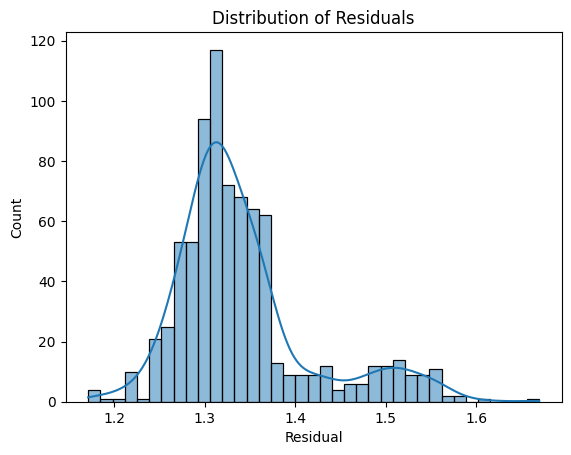

In [24]:
# Residual distribution

residuals = y_true_intensity = y_pred_intensity_test

sns.histplot(residuals, kde=True)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

Highly correlated feature pairs (|corr| > 0.8):


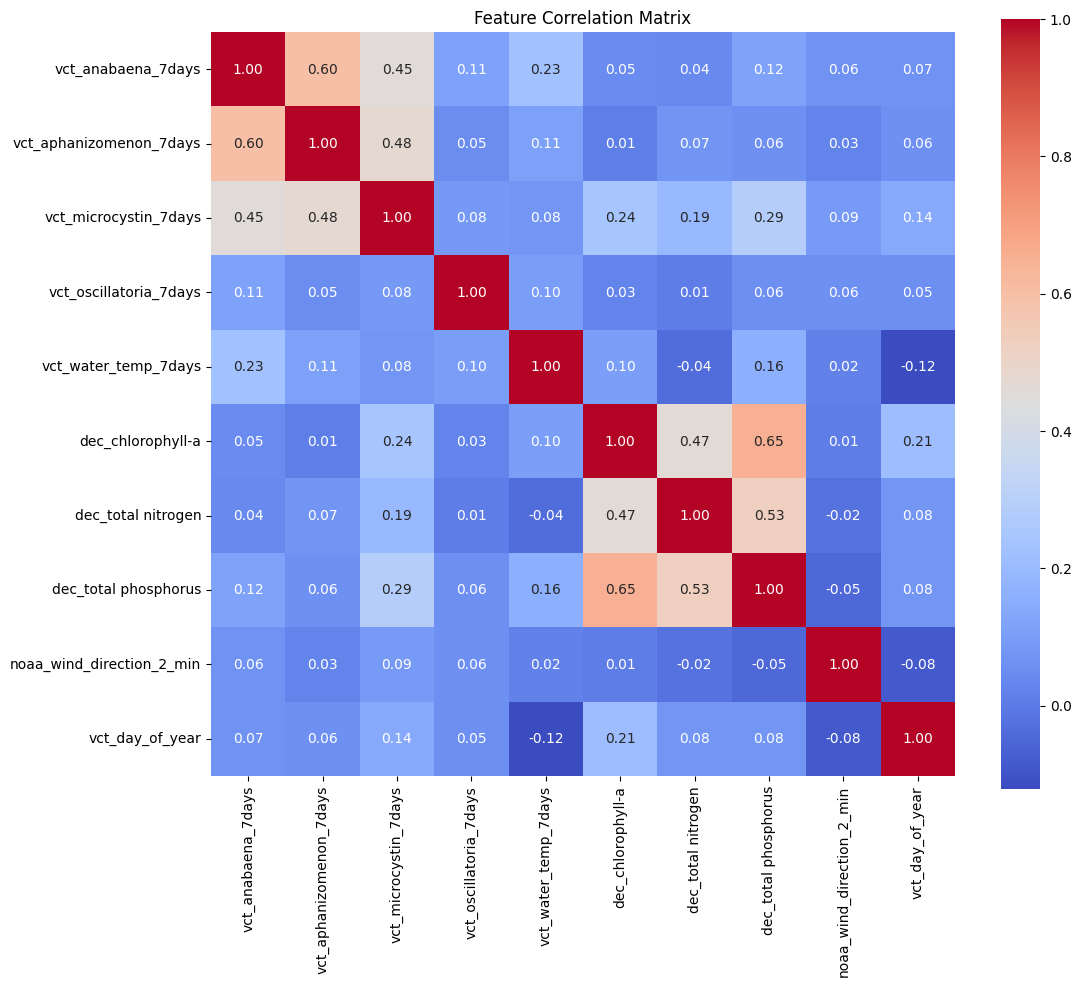

In [25]:
# Step 1: Impute missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_lr_train_features)

# Step 2: Convert to DataFrame using your feature_cols
X_df = pd.DataFrame(X_imputed, columns=feature_cols)

# Step 3: Compute correlation matrix
corr_matrix = X_df.corr()

# Step 4: Identify highly correlated features
threshold = 0.8  # adjust threshold as needed
high_corr = np.where(np.abs(corr_matrix) > threshold)
high_corr_pairs = [(feature_cols[i], feature_cols[j], corr_matrix.iloc[i, j])
                   for i, j in zip(*high_corr) if i < j]  # i<j to avoid duplicates

print("Highly correlated feature pairs (|corr| > 0.8):")
for f1, f2, corr in high_corr_pairs:
    print(f"{f1} ↔ {f2} : {corr:.2f}")

# Step 5: Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.show()